# NDJF Objective Subtype Features and Clustering

This notebook builds the first objective JPCZ subtype feature table from ERA5-derived fields and then tests whether the events separate naturally in feature space.

This notebook is for **objective forcing/modifier analysis**, not event detection.

Primary goals:
- compute interpretable event-level features from `del dot u`, `del cross u`, `850 hPa` geopotential-height anomaly, and `850 hPa` temperature-gradient magnitude
- inspect 2D and 3D scatterplots before clustering
- run a first hierarchical clustering experiment on the feature table
- compare the resulting clusters against later subjective interpretation without training on those labels


In [2]:
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/angelicasophyaramirez-blip/JPCZcatalogcolab.git"
BRANCH = "main"
REPO_DIR = "/content/JPCZcatalog"
FORCE_REFRESH_REPO = True
PERSIST_OUTPUTS_TO_DRIVE = True
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/JPCZcatalog_outputs"

if PERSIST_OUTPUTS_TO_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print("Persistent output dir:", DRIVE_OUTPUT_DIR)

os.chdir("/content")

if FORCE_REFRESH_REPO and os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print("Removed existing repo clone:", REPO_DIR)

if not os.path.exists(REPO_DIR):
    proc = subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, REPO_DIR],
        text=True,
        capture_output=True,
    )
    print(proc.stdout)
    print(proc.stderr)
    if proc.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{proc.stderr}")

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements-colab.txt"],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR],
        check=True,
    )
else:
    print("Using existing repo clone:", REPO_DIR)

os.chdir(REPO_DIR)
src_dir = os.path.join(REPO_DIR, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

print("Working directory:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persistent output dir: /content/drive/MyDrive/JPCZcatalog_outputs
Removed existing repo clone: /content/JPCZcatalog

Cloning into '/content/JPCZcatalog'...

Working directory: /content/JPCZcatalog


In [3]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from jpcz_catalog.analysis import add_japan_local_time_columns
from jpcz_catalog.config import (
    COASTAL_JAPAN_BOX,
    HOKKAIDO_BOX,
    HOKKAIDO_FRONT_BOX,
    OBJECTIVE_SUBTYPE_DOMAIN,
    PACIFIC_EAST_OF_JAPAN_BOX,
    PACIFIC_FRONT_BOX,
    SEA_OF_JAPAN_BOX,
)
from jpcz_catalog.era5 import open_arco_era5
from jpcz_catalog.subtypes import (
    assign_hierarchical_clusters,
    build_objective_subtype_feature_table,
    compute_mean_silhouette_score,
    compute_monthly_geopotential_height_climatology,
    compute_pca_scores,
    evaluate_hierarchical_cluster_solutions,
    feature_definitions_dataframe,
    standardize_feature_table,
)

REVIEW_CATALOG_PATH = Path(DRIVE_OUTPUT_DIR) / "jpcz_catalog_ndjf_merged_12h_manual_verification.csv"
FEATURE_TABLE_PATH = Path("outputs/verification/jpcz_catalog_ndjf_objective_subtype_features.csv")
CLUSTER_TABLE_PATH = Path("outputs/verification/jpcz_catalog_ndjf_objective_subtype_features_with_clusters.csv")
CLUSTER_QUALITY_PATH = Path("outputs/verification/jpcz_catalog_ndjf_cluster_quality_scan.csv")
FEATURE_DICTIONARY_PATH = Path("outputs/verification/jpcz_catalog_ndjf_objective_feature_dictionary.csv")
CLIMATOLOGY_PATH = Path("outputs/verification/z850_ndjf_monthly_climatology.nc")
SCATTER_DIR = Path("outputs/verification/objective_subtype_scatterplots")
SCATTER_DIR.mkdir(parents=True, exist_ok=True)
RUN_EXPORT_DIR = Path("outputs/verification/objective_subtype_runs")
RUN_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

SUBTYPE_DOMAIN = OBJECTIVE_SUBTYPE_DOMAIN

USE_ONLY_VERIFIED_YES = False
FORCE_REBUILD_Z850_CLIMATOLOGY = False
FORCE_REBUILD_FEATURE_TABLE = True
SAVE_PLOTS = True
ERA5_TIME_CHUNK = 48

CLUSTER_FEATURE_COLUMNS = [
    "coastal_to_jpcz_mean_divergence_ratio",
    "hokkaido_min_z850_anomaly_tminus12_to_tplus12",
    "front_box_max_temp_gradient_850_tminus12_to_tplus12",
    "sea_of_japan_mean_vorticity_peak_925",
]
CLUSTER_COUNT_OPTIONS = [2, 3, 4, 5, 6]
N_CLUSTERS = 4
HIERARCHICAL_METHOD = "ward"

SCATTER_XY_PLOTS = [
    ("coastal_to_jpcz_mean_divergence_ratio", "jpcz_polygon_min_divergence_peak_925"),
    ("coastal_to_jpcz_mean_divergence_ratio", "hokkaido_min_z850_anomaly_tminus12_to_tplus12"),
    ("pacific_to_jpcz_mean_divergence_ratio", "front_box_max_temp_gradient_850_tminus12_to_tplus12"),
    ("sea_of_japan_mean_vorticity_peak_925", "hokkaido_min_z850_anomaly_tminus12_to_tplus12"),
]

FEATURE_DICTIONARY = feature_definitions_dataframe()
FEATURE_UNITS = FEATURE_DICTIONARY.set_index("column_name")["units"].to_dict()


def axis_label(column_name: str) -> str:
    units = FEATURE_UNITS.get(column_name)
    if units is None or units == "unitless":
        return column_name
    return f"{column_name}\n[{units}]"


REGION_TABLE = pd.DataFrame(
    [
        {"name": "Coastal Japan box", **COASTAL_JAPAN_BOX.__dict__},
        {"name": "Pacific east of Japan box", **PACIFIC_EAST_OF_JAPAN_BOX.__dict__},
        {"name": "Hokkaido box", **HOKKAIDO_BOX.__dict__},
        {"name": "Sea of Japan box", **SEA_OF_JAPAN_BOX.__dict__},
        {"name": "Hokkaido front box", **HOKKAIDO_FRONT_BOX.__dict__},
        {"name": "Pacific front box", **PACIFIC_FRONT_BOX.__dict__},
    ]
)


def maybe_copy_to_drive(path: Path):
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if path.is_file():
        shutil.copy2(path, drive_path)
        print("Copied to Drive:", drive_path)


def restore_from_drive_cache(path: Path) -> bool:
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return False
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if not drive_path.exists():
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(drive_path, path)
    print("Restored from Drive:", drive_path, "->", path)
    return True


In [4]:
# This cell can be rerun independently if earlier config cells were skipped.
from pathlib import Path
import pandas as pd

from jpcz_catalog.analysis import add_japan_local_time_columns
from jpcz_catalog.config import (
    COASTAL_JAPAN_BOX,
    HOKKAIDO_BOX,
    HOKKAIDO_FRONT_BOX,
    PACIFIC_EAST_OF_JAPAN_BOX,
    PACIFIC_FRONT_BOX,
    SEA_OF_JAPAN_BOX,
)
from jpcz_catalog.subtypes import feature_definitions_dataframe

if "DRIVE_OUTPUT_DIR" not in globals():
    DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/JPCZcatalog_outputs"
if "REVIEW_CATALOG_PATH" not in globals():
    REVIEW_CATALOG_PATH = Path(DRIVE_OUTPUT_DIR) / "jpcz_catalog_ndjf_merged_12h_manual_verification.csv"
if "USE_ONLY_VERIFIED_YES" not in globals():
    USE_ONLY_VERIFIED_YES = False
if "REGION_TABLE" not in globals():
    REGION_TABLE = pd.DataFrame(
        [
            {"name": "Coastal Japan box", **COASTAL_JAPAN_BOX.__dict__},
            {"name": "Pacific east of Japan box", **PACIFIC_EAST_OF_JAPAN_BOX.__dict__},
            {"name": "Hokkaido box", **HOKKAIDO_BOX.__dict__},
            {"name": "Sea of Japan box", **SEA_OF_JAPAN_BOX.__dict__},
            {"name": "Hokkaido front box", **HOKKAIDO_FRONT_BOX.__dict__},
            {"name": "Pacific front box", **PACIFIC_FRONT_BOX.__dict__},
        ]
    )
if "FEATURE_DICTIONARY" not in globals():
    FEATURE_DICTIONARY = feature_definitions_dataframe()
if "FEATURE_DICTIONARY_PATH" not in globals():
    FEATURE_DICTIONARY_PATH = Path("outputs/verification/jpcz_catalog_ndjf_objective_feature_dictionary.csv")

review_df = pd.read_csv(
    REVIEW_CATALOG_PATH,
    parse_dates=["event_start", "event_end", "event_peak"],
)
review_df = add_japan_local_time_columns(review_df)

if USE_ONLY_VERIFIED_YES:
    working_df = review_df[review_df["verified_event"].fillna("") == "yes"].copy()
else:
    working_df = review_df.copy()

working_df["event_peak"] = pd.to_datetime(working_df["event_peak"])
event_years = sorted(working_df["event_peak"].dt.year.unique())
CLIMATOLOGY_MONTHS = sorted({
    (pd.Timestamp(peak_time) + pd.Timedelta(hours=offset)).month
    for peak_time in working_df["event_peak"]
    for offset in (-12, 0, 12)
})
print("Climatology months needed for t-12/t0/t+12:", CLIMATOLOGY_MONTHS)

FEATURE_DICTIONARY.to_csv(FEATURE_DICTIONARY_PATH, index=False)
if "maybe_copy_to_drive" in globals():
    maybe_copy_to_drive(FEATURE_DICTIONARY_PATH)

print("Total catalog rows:", len(review_df))
print("Rows used for objective subtype features:", len(working_df))
print("Event years represented:", event_years[0], "to", event_years[-1])

print("\nCharacterization regions")
display(REGION_TABLE)

print("\nObjective feature dictionary")
display(FEATURE_DICTIONARY)


Climatology months needed for t-12/t0/t+12: [1, 2, 3, 10, 11, 12]
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/jpcz_catalog_ndjf_objective_feature_dictionary.csv
Total catalog rows: 201
Rows used for objective subtype features: 201
Event years represented: 2000 to 2018

Characterization regions


,name,lon_min,lon_max,lat_min,lat_max
0,Coastal Japan box,131.0,140.0,34.0,40.5
1,Pacific east of Japan box,141.0,150.0,33.0,42.0
2,Hokkaido box,139.0,146.5,41.0,46.5
3,Sea of Japan box,129.0,140.0,36.0,45.0
4,Hokkaido front box,136.0,147.0,39.0,47.0
5,Pacific front box,141.0,151.0,33.0,42.0



Objective feature dictionary


,column_name,units,meaning,formula,calculation,interpretation,region,time_window,purpose
0,jpcz_polygon_mean_divergence_peak_925,1e-5 s^-1,Area-weighted mean signed divergence in the or...,mean_polygon(div925),Compute 925 hPa divergence from ERA5 u and v a...,More negative values mean stronger polygon-mea...,Original JPCZ polygon,event peak only,Canonical signed divergence metric in the Shin...
1,jpcz_polygon_min_divergence_peak_925,1e-5 s^-1,Most negative signed divergence value in the o...,min_polygon(div925),Minimum of the signed divergence field inside ...,More negative values mean a stronger local con...,Original JPCZ polygon,event peak only,Captures the strongest local convergence cente...
2,coastal_japan_mean_divergence_peak_925,1e-5 s^-1,Area-weighted mean signed divergence in the co...,mean_coast(div925),"Same signed divergence field as above, summari...",More negative values mean stronger coastal-Jap...,Coastal Japan box,event peak only,Measures whether the event is more convergent ...
3,coastal_japan_min_divergence_peak_925,1e-5 s^-1,Most negative signed divergence value in the c...,min_coast(div925),Minimum of the signed divergence field in the ...,More negative values mean a stronger local coa...,Coastal Japan box,event peak only,Captures the strongest coastal convergence cen...
4,coastal_to_jpcz_mean_divergence_ratio,unitless,Ratio of coastal-Japan mean signed divergence ...,coastal_japan_mean_divergence_peak_925 / jpcz_...,coastal_japan_mean_divergence_peak_925 / jpcz_...,"When both regional means are negative, values ...",Coastal Japan vs JPCZ polygon,event peak only,Measures how the coastal signed-divergence mea...
5,coastal_to_jpcz_min_divergence_ratio,unitless,Ratio of the coastal-Japan minimum signed dive...,coastal_japan_min_divergence_peak_925 / jpcz_p...,coastal_japan_min_divergence_peak_925 / jpcz_p...,"When both extrema are negative, values > 1 mea...",Coastal Japan vs JPCZ polygon,event peak only,Alternative coastal-enhancement metric based o...
6,pacific_east_of_japan_mean_divergence_peak_925,1e-5 s^-1,Area-weighted mean signed divergence east of J...,mean_pacific(div925),"Same signed divergence field as above, summari...",More negative values mean stronger Pacific-sid...,Pacific east of Japan box,event peak only,Measures whether the event is coupled to stron...
7,pacific_east_of_japan_min_divergence_peak_925,1e-5 s^-1,Most negative signed divergence value east of ...,min_pacific(div925),Minimum of the signed divergence field in the ...,More negative values mean a stronger local Pac...,Pacific east of Japan box,event peak only,Captures the strongest Pacific-side convergenc...
8,pacific_to_jpcz_mean_divergence_ratio,unitless,Ratio of Pacific-box mean signed divergence to...,pacific_east_of_japan_mean_divergence_peak_925...,pacific_east_of_japan_mean_divergence_peak_925...,"When both regional means are negative, values ...",Pacific east of Japan vs JPCZ polygon,event peak only,Measures how strongly the event is coupled to ...
9,pacific_to_jpcz_min_divergence_ratio,unitless,Ratio of the Pacific-box minimum signed diverg...,pacific_east_of_japan_min_divergence_peak_925 ...,pacific_east_of_japan_min_divergence_peak_925 ...,"When both extrema are negative, values > 1 mea...",Pacific east of Japan vs JPCZ polygon,event peak only,Alternative Pacific-coupling metric based on l...


In [5]:
# This cell can recover if the imports/config cell was skipped or deleted.
from pathlib import Path
import shutil

import pandas as pd
import xarray as xr

from jpcz_catalog.analysis import add_japan_local_time_columns
from jpcz_catalog.config import (
    COASTAL_JAPAN_BOX,
    HOKKAIDO_BOX,
    HOKKAIDO_FRONT_BOX,
    OBJECTIVE_SUBTYPE_DOMAIN,
    PACIFIC_EAST_OF_JAPAN_BOX,
    PACIFIC_FRONT_BOX,
    SEA_OF_JAPAN_BOX,
)
from jpcz_catalog.era5 import open_arco_era5
from jpcz_catalog.subtypes import (
    assign_hierarchical_clusters,
    build_objective_subtype_feature_table,
    compute_mean_silhouette_score,
    compute_monthly_geopotential_height_climatology,
    compute_pca_scores,
    evaluate_hierarchical_cluster_solutions,
    feature_definitions_dataframe,
    standardize_feature_table,
)

if "DRIVE_OUTPUT_DIR" not in globals():
    DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/JPCZcatalog_outputs"
if "PERSIST_OUTPUTS_TO_DRIVE" not in globals():
    PERSIST_OUTPUTS_TO_DRIVE = True
if "REVIEW_CATALOG_PATH" not in globals():
    REVIEW_CATALOG_PATH = Path(DRIVE_OUTPUT_DIR) / "jpcz_catalog_ndjf_merged_12h_manual_verification.csv"
if "FEATURE_TABLE_PATH" not in globals():
    FEATURE_TABLE_PATH = Path("outputs/verification/jpcz_catalog_ndjf_objective_subtype_features.csv")
if "CLUSTER_TABLE_PATH" not in globals():
    CLUSTER_TABLE_PATH = Path("outputs/verification/jpcz_catalog_ndjf_objective_subtype_features_with_clusters.csv")
if "CLUSTER_QUALITY_PATH" not in globals():
    CLUSTER_QUALITY_PATH = Path("outputs/verification/jpcz_catalog_ndjf_cluster_quality_scan.csv")
if "FEATURE_DICTIONARY_PATH" not in globals():
    FEATURE_DICTIONARY_PATH = Path("outputs/verification/jpcz_catalog_ndjf_objective_feature_dictionary.csv")
if "CLIMATOLOGY_PATH" not in globals():
    CLIMATOLOGY_PATH = Path("outputs/verification/z850_ndjf_monthly_climatology.nc")
if "SCATTER_DIR" not in globals():
    SCATTER_DIR = Path("outputs/verification/objective_subtype_scatterplots")
    SCATTER_DIR.mkdir(parents=True, exist_ok=True)
if "USE_ONLY_VERIFIED_YES" not in globals():
    USE_ONLY_VERIFIED_YES = False
if "FORCE_REBUILD_Z850_CLIMATOLOGY" not in globals():
    FORCE_REBUILD_Z850_CLIMATOLOGY = False
if "FORCE_REBUILD_FEATURE_TABLE" not in globals():
    FORCE_REBUILD_FEATURE_TABLE = True
if "SAVE_PLOTS" not in globals():
    SAVE_PLOTS = True
if "ERA5_TIME_CHUNK" not in globals():
    ERA5_TIME_CHUNK = 48
if "CLUSTER_FEATURE_COLUMNS" not in globals():
    CLUSTER_FEATURE_COLUMNS = [
        "coastal_to_jpcz_mean_divergence_ratio",
        "hokkaido_min_z850_anomaly_tminus12_to_tplus12",
        "front_box_max_temp_gradient_850_tminus12_to_tplus12",
        "sea_of_japan_mean_vorticity_peak_925",
    ]
if "CLUSTER_COUNT_OPTIONS" not in globals():
    CLUSTER_COUNT_OPTIONS = [2, 3, 4, 5, 6]
if "N_CLUSTERS" not in globals():
    N_CLUSTERS = 4
if "HIERARCHICAL_METHOD" not in globals():
    HIERARCHICAL_METHOD = "ward"
if "SCATTER_XY_PLOTS" not in globals():
    SCATTER_XY_PLOTS = [
        ("coastal_to_jpcz_mean_divergence_ratio", "jpcz_polygon_min_divergence_peak_925"),
        ("coastal_to_jpcz_mean_divergence_ratio", "hokkaido_min_z850_anomaly_tminus12_to_tplus12"),
        ("pacific_to_jpcz_mean_divergence_ratio", "front_box_max_temp_gradient_850_tminus12_to_tplus12"),
        ("sea_of_japan_mean_vorticity_peak_925", "hokkaido_min_z850_anomaly_tminus12_to_tplus12"),
    ]
if "maybe_copy_to_drive" not in globals():
    def maybe_copy_to_drive(path: Path):
        if not PERSIST_OUTPUTS_TO_DRIVE:
            return
        drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
        if path.is_file():
            shutil.copy2(path, drive_path)
            print("Copied to Drive:", drive_path)
if "FEATURE_DICTIONARY" not in globals():
    FEATURE_DICTIONARY = feature_definitions_dataframe()
if "FEATURE_UNITS" not in globals():
    FEATURE_UNITS = FEATURE_DICTIONARY.set_index("column_name")["units"].to_dict()
if "axis_label" not in globals():
    def axis_label(column_name: str) -> str:
        units = FEATURE_UNITS.get(column_name)
        if units is None or units == "unitless":
            return column_name
        return f"{column_name}\n[{units}]"
if "REGION_TABLE" not in globals():
    REGION_TABLE = pd.DataFrame(
        [
            {"name": "Coastal Japan box", **COASTAL_JAPAN_BOX.__dict__},
            {"name": "Pacific east of Japan box", **PACIFIC_EAST_OF_JAPAN_BOX.__dict__},
            {"name": "Hokkaido box", **HOKKAIDO_BOX.__dict__},
            {"name": "Sea of Japan box", **SEA_OF_JAPAN_BOX.__dict__},
            {"name": "Hokkaido front box", **HOKKAIDO_FRONT_BOX.__dict__},
            {"name": "Pacific front box", **PACIFIC_FRONT_BOX.__dict__},
        ]
    )

if "working_df" not in globals() or "event_years" not in globals():
    review_df = pd.read_csv(
        REVIEW_CATALOG_PATH,
        parse_dates=["event_start", "event_end", "event_peak"],
    )
    review_df = add_japan_local_time_columns(review_df)
    if USE_ONLY_VERIFIED_YES:
        working_df = review_df[review_df["verified_event"].fillna("") == "yes"].copy()
    else:
        working_df = review_df.copy()
    working_df["event_peak"] = pd.to_datetime(working_df["event_peak"])
    event_years = sorted(working_df["event_peak"].dt.year.unique())
    CLIMATOLOGY_MONTHS = sorted({
        (pd.Timestamp(peak_time) + pd.Timedelta(hours=offset)).month
        for peak_time in working_df["event_peak"]
        for offset in (-12, 0, 12)
    })

ds = open_arco_era5(chunks={"time": ERA5_TIME_CHUNK})

if not CLIMATOLOGY_PATH.exists() and "restore_from_drive_cache" in globals():
    restore_from_drive_cache(CLIMATOLOGY_PATH)

if CLIMATOLOGY_PATH.exists() and not FORCE_REBUILD_Z850_CLIMATOLOGY:
    z850_climatology = xr.open_dataarray(CLIMATOLOGY_PATH).load()
    cached_months = {int(month_value) for month_value in z850_climatology["month"].values.tolist()}
else:
    z850_climatology = None
    cached_months = set()

missing_months = sorted(set(CLIMATOLOGY_MONTHS) - cached_months)
if missing_months:
    print("Cached climatology missing months:", missing_months)
    print("Computing missing climatology months one at a time and checkpointing each month to Drive.")
    for month in missing_months:
        month_climatology = compute_monthly_geopotential_height_climatology(
            ds,
            years=event_years,
            months=[month],
            level=850,
        )
        if z850_climatology is None:
            z850_climatology = month_climatology
        else:
            z850_climatology = xr.concat([z850_climatology, month_climatology], dim="month").sortby("month")
        z850_climatology.to_netcdf(CLIMATOLOGY_PATH)
        maybe_copy_to_drive(CLIMATOLOGY_PATH)
        print(f"Checkpointed climatology after month {month:02d}")
    climatology_source = Path("month-by-month climatology checkpoints")
else:
    climatology_source = Path("restored cached climatology")

print("Z850 climatology source:", climatology_source)
print("Required climatology months:", CLIMATOLOGY_MONTHS)
print("Available climatology months:", z850_climatology["month"].values.tolist())
display((z850_climatology.mean(dim=("latitude", "longitude")).to_series()).rename("domain_mean_gpm"))


Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/z850_ndjf_monthly_climatology.nc -> outputs/verification/z850_ndjf_monthly_climatology.nc
Z850 climatology source: restored cached climatology
Required climatology months: [1, 2, 3, 10, 11, 12]
Available climatology months: [1, 2, 3, 10, 11, 12]


,domain_mean_gpm
month,
1,1402.783569
2,1408.915405
3,1414.997070
10,1488.287720
11,1460.382568
12,1417.276733


In [6]:
if not FEATURE_TABLE_PATH.exists() and "restore_from_drive_cache" in globals():
    restore_from_drive_cache(FEATURE_TABLE_PATH)

if FEATURE_TABLE_PATH.exists() and not FORCE_REBUILD_FEATURE_TABLE:
    feature_df = pd.read_csv(
        FEATURE_TABLE_PATH,
        parse_dates=["event_start", "event_end", "event_peak"],
    )
    feature_source = Path("restored cached feature table")
else:
    feature_df = build_objective_subtype_feature_table(
        ds,
        working_df,
        z850_climatology=z850_climatology,
        progress_every=10,
    )
    feature_df.to_csv(FEATURE_TABLE_PATH, index=False)
    maybe_copy_to_drive(FEATURE_TABLE_PATH)
    feature_source = Path("recomputed from ERA5 feature helpers")

print("Feature table source:", feature_source)
print("Feature rows:", len(feature_df))
preview_columns = [
    "event_peak",
    "event_peak_jst",
    "event_peak_D_1e5_s-1",
    "duration_hours",
    "verified_event",
    "pattern_type_manual",
] + CLUSTER_FEATURE_COLUMNS

display(feature_df.reindex(columns=preview_columns).head(20))


Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/jpcz_catalog_ndjf_objective_subtype_features.csv -> outputs/verification/jpcz_catalog_ndjf_objective_subtype_features.csv
Built objective subtype features for 10/201 events
Built objective subtype features for 20/201 events
Built objective subtype features for 30/201 events
Built objective subtype features for 40/201 events
Built objective subtype features for 50/201 events
Built objective subtype features for 60/201 events
Built objective subtype features for 70/201 events
Built objective subtype features for 80/201 events
Built objective subtype features for 90/201 events
Built objective subtype features for 100/201 events
Built objective subtype features for 110/201 events
Built objective subtype features for 120/201 events
Built objective subtype features for 130/201 events
Built objective subtype features for 140/201 events
Built objective subtype features for 150/201 events
Built objective subtype features for 160/20

,event_peak,event_peak_jst,event_peak_D_1e5_s-1,duration_hours,verified_event,pattern_type_manual,coastal_to_jpcz_mean_divergence_ratio,hokkaido_min_z850_anomaly_tminus12_to_tplus12,front_box_max_temp_gradient_850_tminus12_to_tplus12,sea_of_japan_mean_vorticity_peak_925
0,2000-01-05 23:00:00,2000-01-06 08:00:00,-2.438026,2,yes,NaN,0.158451,15.484619,13.136884,1.331250
1,2000-01-13 11:00:00,2000-01-13 20:00:00,-2.972377,7,yes,NaN,0.588960,-61.364014,11.990105,1.148119
2,2000-01-20 04:00:00,2000-01-20 13:00:00,-2.927972,11,yes,NaN,0.374037,-71.055664,10.089020,1.364941
3,2000-02-08 00:00:00,2000-02-08 09:00:00,-4.312036,25,yes,NaN,0.441577,-165.337036,11.640176,1.987986
4,2000-02-14 22:00:00,2000-02-15 07:00:00,-3.603144,56,yes,NaN,0.389202,-204.541138,13.789076,0.281145
5,2000-02-17 09:00:00,2000-02-17 18:00:00,-1.969221,3,yes,NaN,0.342314,-106.121582,11.619072,0.225369
6,2000-02-27 23:00:00,2000-02-28 08:00:00,-3.168735,11,yes,NaN,0.781035,-47.673584,13.337569,1.735183
7,2000-11-10 13:00:00,2000-11-10 22:00:00,-2.066867,8,yes,NaN,0.598225,-52.897949,18.867779,0.053652
8,2000-11-17 10:00:00,2000-11-17 19:00:00,-2.043299,4,yes,NaN,0.951497,-89.733154,12.692460,1.010501
9,2000-11-20 05:00:00,2000-11-20 14:00:00,-2.018676,7,yes,NaN,2.242250,-163.738037,15.829692,2.318083


In [7]:
summary_columns = [
    "jpcz_polygon_mean_divergence_peak_925",
    "jpcz_polygon_min_divergence_peak_925",
    "coastal_japan_mean_divergence_peak_925",
    "coastal_to_jpcz_mean_divergence_ratio",
    "pacific_to_jpcz_mean_divergence_ratio",
    "sea_of_japan_mean_vorticity_peak_925",
    "hokkaido_min_z850_anomaly_tminus12_to_tplus12",
    "sea_of_japan_min_z850_anomaly_tminus12_to_tplus12",
    "front_box_max_temp_gradient_850_tminus12_to_tplus12",
    "pacific_box_max_temp_gradient_850_tminus12_to_tplus12",
]

overall_feature_summary_stats = feature_df.loc[:, summary_columns].describe().T
overall_feature_summary_path = RUN_EXPORT_DIR / "overall_feature_summary_stats.csv"
overall_feature_summary_stats.to_csv(overall_feature_summary_path)
maybe_copy_to_drive(overall_feature_summary_path)

print("Overall feature summary statistics (independent of k)")
print("These describe the full objective feature table, so they should not change when only N_CLUSTERS changes.")
display(overall_feature_summary_stats)


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/overall_feature_summary_stats.csv
Overall feature summary statistics (independent of k)
These describe the full objective feature table, so they should not change when only N_CLUSTERS changes.


,count,mean,std,min,25%,50%,75%,max
jpcz_polygon_mean_divergence_peak_925,201.0,-2.175861,0.785389,-4.780436,-2.626144,-2.120996,-1.639784,0.045243
jpcz_polygon_min_divergence_peak_925,201.0,-17.001785,5.417078,-40.204863,-19.755561,-16.023541,-13.216024,-7.564374
coastal_japan_mean_divergence_peak_925,201.0,-1.042335,0.663600,-2.834568,-1.483349,-0.982277,-0.543571,0.284611
coastal_to_jpcz_mean_divergence_ratio,201.0,0.586299,0.590889,-0.174757,0.259992,0.416133,0.710365,4.293770
pacific_to_jpcz_mean_divergence_ratio,201.0,0.058500,1.001015,-12.748590,-0.180835,0.088406,0.303126,1.885191
sea_of_japan_mean_vorticity_peak_925,201.0,0.928705,1.018889,-1.148207,0.130370,0.849437,1.573352,3.818731
hokkaido_min_z850_anomaly_tminus12_to_tplus12,201.0,-121.404782,81.287631,-469.574768,-167.158203,-124.575562,-61.720947,40.635010
sea_of_japan_min_z850_anomaly_tminus12_to_tplus12,201.0,-120.303085,66.486827,-300.258179,-163.738037,-112.518311,-67.695679,17.929199
front_box_max_temp_gradient_850_tminus12_to_tplus12,201.0,16.748353,7.198115,4.197420,11.640176,15.829692,20.320499,47.607265
pacific_box_max_temp_gradient_850_tminus12_to_tplus12,201.0,8.854962,3.424327,3.815800,6.779626,7.966140,9.921287,22.654887


First-pass objective subtype scatterplots (independent of k)
These plots use the fixed feature table and should stay the same when only N_CLUSTERS changes.
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_subtype_scatterplots.png


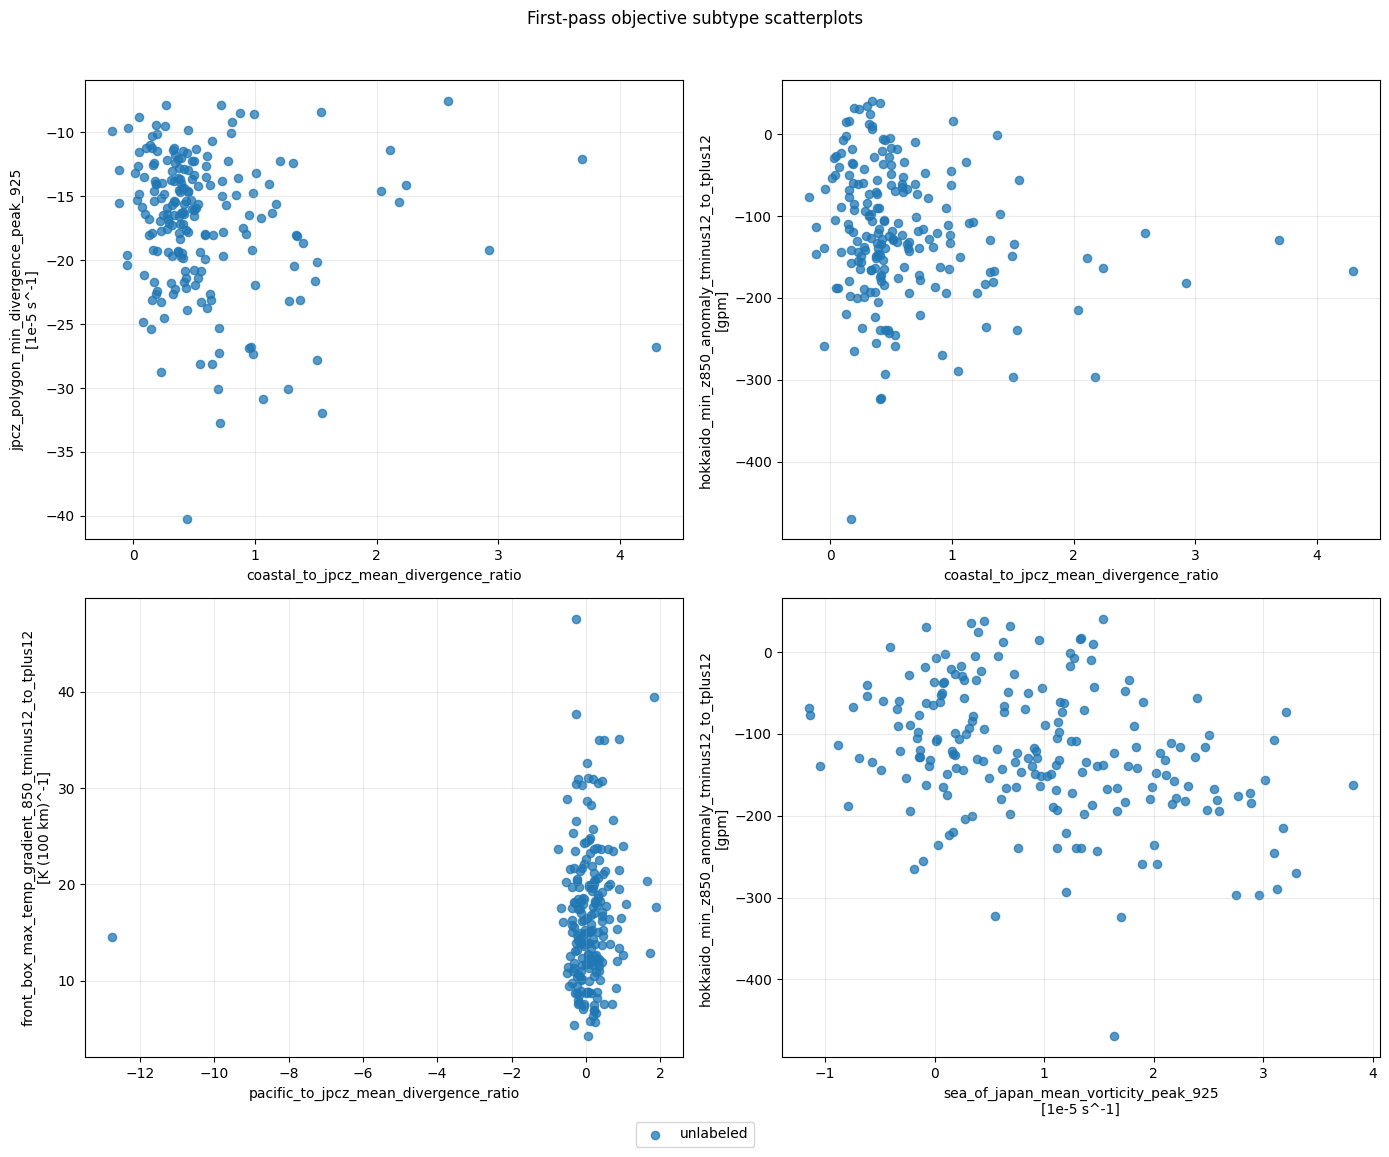

In [8]:
color_column = "pattern_type_manual" if "pattern_type_manual" in feature_df.columns else None
plot_df = feature_df.copy()

if color_column is not None:
    plot_df[color_column] = plot_df[color_column].fillna("").replace("", "unlabeled")
    categories = sorted(plot_df[color_column].unique())
    cmap = plt.get_cmap("tab10")
    color_map = {label: cmap(i % 10) for i, label in enumerate(categories)}
else:
    categories = ["all events"]
    color_map = {"all events": "tab:blue"}

print("First-pass objective subtype scatterplots (independent of k)")
print("These plots use the fixed feature table and should stay the same when only N_CLUSTERS changes.")

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

for ax, (x_name, y_name) in zip(axes, SCATTER_XY_PLOTS):
    if color_column is None:
        ax.scatter(plot_df[x_name], plot_df[y_name], s=35, alpha=0.75, color="tab:blue")
    else:
        for label in categories:
            subset = plot_df[plot_df[color_column] == label]
            ax.scatter(
                subset[x_name],
                subset[y_name],
                s=35,
                alpha=0.75,
                color=color_map[label],
                label=label,
            )
    ax.set_xlabel(axis_label(x_name))
    ax.set_ylabel(axis_label(y_name))
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="lower center", ncol=min(4, len(labels)), bbox_to_anchor=(0.5, -0.02))
fig.suptitle("First-pass objective subtype scatterplots", y=1.02)
fig.tight_layout()

if SAVE_PLOTS:
    scatter_path = SCATTER_DIR / "objective_subtype_scatterplots.png"
    fig.savefig(scatter_path, dpi=170, bbox_inches="tight")
    maybe_copy_to_drive(scatter_path)

plt.show()


Running hierarchical clustering comparison for k=[2, 3, 4] using ward linkage
This cell recomputes every requested k from the same fixed feature table, so the saved outputs are directly comparable.
Cells 6 and 7 remain independent of k because they summarize and plot the raw feature table.
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/jpcz_catalog_ndjf_cluster_quality_scan.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/pca_variance_summary.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_feature_legend.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_medians_k2.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/clustered_events_k2.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_counts_k2.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_quality_selected_k2.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_medians_k3.csv
Copied to 

,feature_column,plot_label,units,meaning,formula,calculation,interpretation,region,time_window,purpose
0,coastal_to_jpcz_mean_divergence_ratio,coastal_to_jpcz_mean_divergence_ratio,unitless,Ratio of coastal-Japan mean signed divergence ...,coastal_japan_mean_divergence_peak_925 / jpcz_...,coastal_japan_mean_divergence_peak_925 / jpcz_...,"When both regional means are negative, values ...",Coastal Japan vs JPCZ polygon,event peak only,Measures how the coastal signed-divergence mea...
1,hokkaido_min_z850_anomaly_tminus12_to_tplus12,hokkaido_min_z850_anomaly_tminus12_to_tplus12\...,gpm,Most negative 850 hPa geopotential-height anom...,"min_{t in [-12,0,+12]} min_hokkaido(z850_event...",Compute z850 anomaly as event-time z850 minus ...,More negative values indicate a deeper passing...,Hokkaido box,"t-12 h, t0, t+12 h",Quantifies passing-low or trough forcing near ...
2,front_box_max_temp_gradient_850_tminus12_to_tp...,front_box_max_temp_gradient_850_tminus12_to_tp...,K (100 km)^-1,Largest 850 hPa horizontal temperature-gradien...,"max_{t in [-12,0,+12]} max_front(|grad T850(t)...",Compute |grad T850| and save the maximum box v...,Larger values indicate stronger frontal or bar...,Hokkaido front box,"t-12 h, t0, t+12 h",Quantifies frontal or baroclinic forcing upstr...
3,sea_of_japan_mean_vorticity_peak_925,sea_of_japan_mean_vorticity_peak_925\n[1e-5 s^-1],1e-5 s^-1,Area-weighted mean relative vorticity in the S...,"mean_soj(zeta925), where zeta925 = dv/dx - du/dy",Compute 925 hPa relative vorticity from ERA5 u...,More positive values indicate stronger cycloni...,Sea of Japan box,event peak only,Quantifies circulation-centered forcing over t...


Cluster feature columns: ['coastal_to_jpcz_mean_divergence_ratio', 'hokkaido_min_z850_anomaly_tminus12_to_tplus12', 'front_box_max_temp_gradient_850_tminus12_to_tplus12', 'sea_of_japan_mean_vorticity_peak_925']
Feature means used for standardization:


,mean
coastal_to_jpcz_mean_divergence_ratio,0.586299
hokkaido_min_z850_anomaly_tminus12_to_tplus12,-121.404782
front_box_max_temp_gradient_850_tminus12_to_tplus12,16.748353
sea_of_japan_mean_vorticity_peak_925,0.928705



Feature standard deviations used for standardization:


...


Cluster medians (k=4)


,jpcz_polygon_mean_divergence_peak_925,jpcz_polygon_min_divergence_peak_925,coastal_japan_mean_divergence_peak_925,coastal_to_jpcz_mean_divergence_ratio,pacific_to_jpcz_mean_divergence_ratio,sea_of_japan_mean_vorticity_peak_925,hokkaido_min_z850_anomaly_tminus12_to_tplus12,sea_of_japan_min_z850_anomaly_tminus12_to_tplus12,front_box_max_temp_gradient_850_tminus12_to_tplus12,pacific_box_max_temp_gradient_850_tminus12_to_tplus12,duration_hours,event_peak_D_1e5_s-1
cluster_ward_4,,,,,,,,,,,,
1,-2.14,-16.24,-0.79,0.34,0.05,0.63,-18.20,-52.17,10.62,7.37,11.0,-2.96
2,-2.22,-15.01,-0.81,0.38,0.10,0.19,-129.21,-110.36,18.27,8.25,10.0,-2.71
3,-2.20,-17.76,-1.49,0.65,0.16,1.96,-192.13,-186.81,30.82,9.63,12.0,-3.21
4,-1.82,-17.78,-1.60,0.85,0.06,1.99,-150.68,-164.91,12.21,7.73,8.0,-2.59



Cluster vs subjective pattern cross-tab (k=4)


pattern_type_manual,unlabeled
cluster_ward_4,
1,42
2,92
3,20
4,47



Saved comparison files to: outputs/verification/objective_subtype_runs
- cluster_comparison_summary.csv
- cluster_counts_comparison.csv
- cluster_medians_comparison_long.csv
- cluster_selection_guide.csv
- pca_variance_summary.csv
- cluster_feature_legend.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_subtype_pca_clusters_ward_k2.png


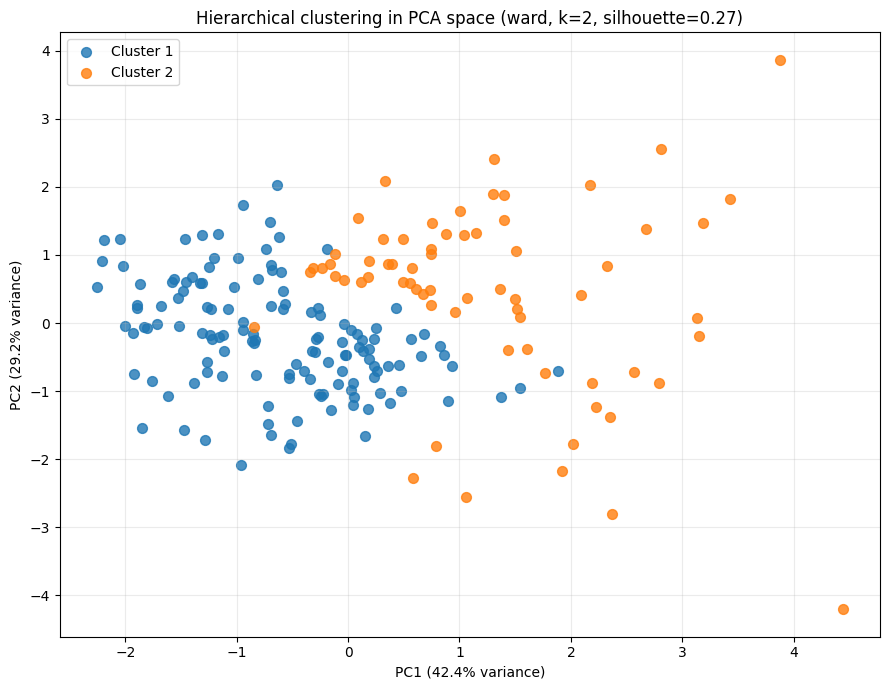

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_subtype_3d_scatter_k2.png


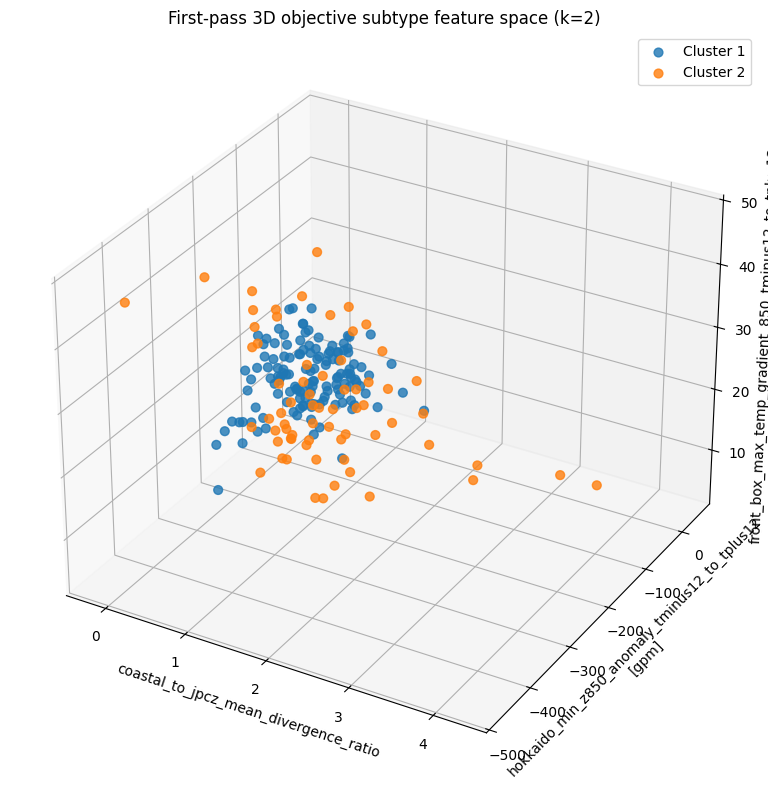

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_subtype_pca_clusters_ward_k3.png


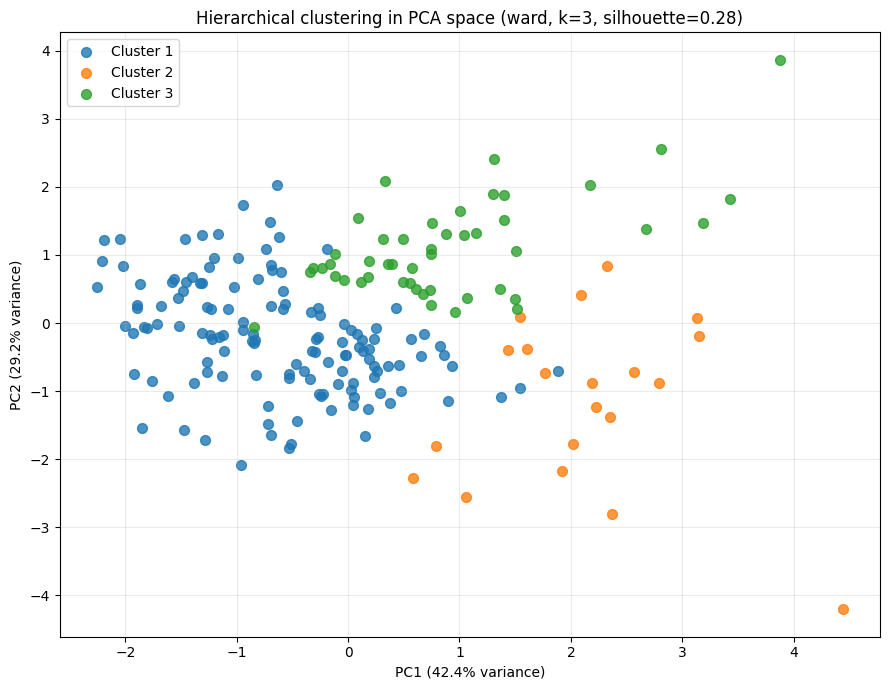

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_subtype_3d_scatter_k3.png


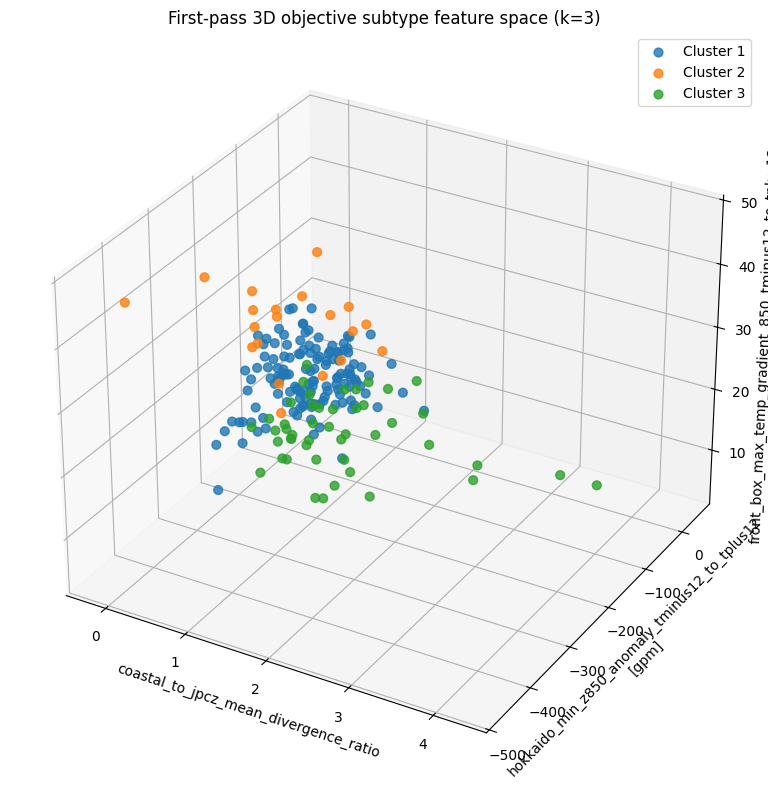

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_subtype_pca_clusters_ward_k4.png


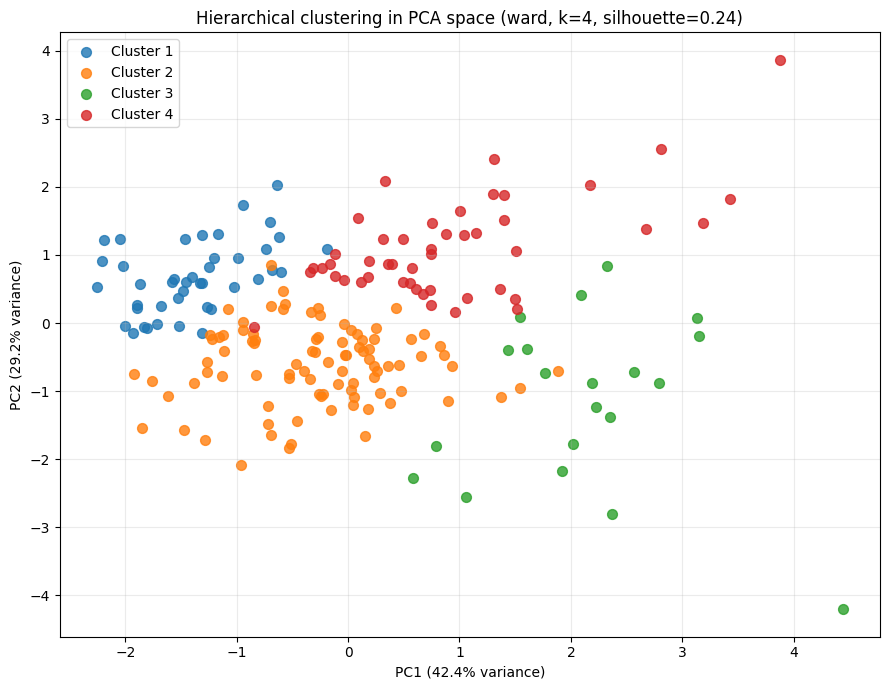

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_subtype_3d_scatter_k4.png


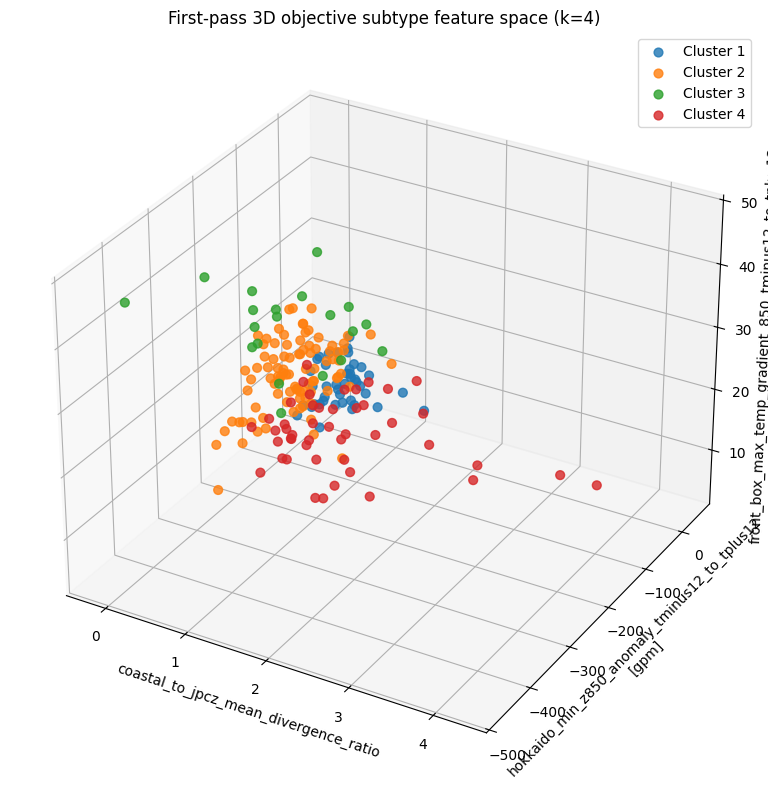

Saved PCA and 3D comparison plots across requested k values


,k,pca_plot_file,scatter3d_plot_file,is_primary_plot_solution
0,2,objective_subtype_pca_clusters_ward_k2.png,objective_subtype_3d_scatter_k2.png,False
1,3,objective_subtype_pca_clusters_ward_k3.png,objective_subtype_3d_scatter_k3.png,True
2,4,objective_subtype_pca_clusters_ward_k4.png,objective_subtype_3d_scatter_k4.png,False


In [9]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Edit this list when rerunning the final clustering comparison step.
RUN_CLUSTER_K_VALUES = [2, 3, 4]
PRIMARY_K_FOR_PLOTS = 3
RUN_CLUSTER_METHOD = HIERARCHICAL_METHOD

print(
    f"Running hierarchical clustering comparison for k={RUN_CLUSTER_K_VALUES} "
    f"using {RUN_CLUSTER_METHOD} linkage"
)
print(
    "This cell recomputes every requested k from the same fixed feature table, "
    "so the saved outputs are directly comparable."
)
print(
    "Cells 6 and 7 remain independent of k because they summarize and plot the raw feature table."
)

cluster_input_df = feature_df.copy()
standardized_df, feature_means, feature_stds = standardize_feature_table(
    cluster_input_df,
    columns=CLUSTER_FEATURE_COLUMNS,
)

cluster_quality_df = evaluate_hierarchical_cluster_solutions(
    standardized_df,
    cluster_counts=CLUSTER_COUNT_OPTIONS,
    method=RUN_CLUSTER_METHOD,
)
cluster_quality_df.to_csv(CLUSTER_QUALITY_PATH, index=False)
maybe_copy_to_drive(CLUSTER_QUALITY_PATH)

pca_scores, explained_variance_ratio = compute_pca_scores(standardized_df, n_components=3)
pca_summary_df = pd.DataFrame(
    {
        "principal_component": [f"PC{i + 1}" for i in range(len(explained_variance_ratio))],
        "explained_variance_ratio": explained_variance_ratio,
        "explained_variance_percent": explained_variance_ratio * 100.0,
        "cumulative_explained_variance_ratio": np.cumsum(explained_variance_ratio),
        "cumulative_explained_variance_percent": np.cumsum(explained_variance_ratio) * 100.0,
    }
)
pca_summary_path = RUN_EXPORT_DIR / "pca_variance_summary.csv"
pca_summary_df.to_csv(pca_summary_path, index=False)
maybe_copy_to_drive(pca_summary_path)

cluster_feature_legend_df = (
    FEATURE_DICTIONARY.set_index("column_name")
    .loc[
        CLUSTER_FEATURE_COLUMNS,
        ["units", "meaning", "formula", "calculation", "interpretation", "region", "time_window", "purpose"],
    ]
    .reset_index()
    .rename(columns={"column_name": "feature_column"})
)
cluster_feature_legend_df.insert(
    1,
    "plot_label",
    [axis_label(column_name) for column_name in cluster_feature_legend_df["feature_column"]],
)
cluster_feature_legend_path = RUN_EXPORT_DIR / "cluster_feature_legend.csv"
cluster_feature_legend_df.to_csv(cluster_feature_legend_path, index=False)
maybe_copy_to_drive(cluster_feature_legend_path)

interpret_cols = [
    "jpcz_polygon_mean_divergence_peak_925",
    "jpcz_polygon_min_divergence_peak_925",
    "coastal_japan_mean_divergence_peak_925",
    "coastal_to_jpcz_mean_divergence_ratio",
    "pacific_to_jpcz_mean_divergence_ratio",
    "sea_of_japan_mean_vorticity_peak_925",
    "hokkaido_min_z850_anomaly_tminus12_to_tplus12",
    "sea_of_japan_min_z850_anomaly_tminus12_to_tplus12",
    "front_box_max_temp_gradient_850_tminus12_to_tplus12",
    "pacific_box_max_temp_gradient_850_tminus12_to_tplus12",
    "duration_hours",
    "event_peak_D_1e5_s-1",
]

comparison_rows = []
counts_frames = []
medians_frames = []
clustered_runs = {}
primary_cluster_labels = None
primary_cluster_col = None
primary_selected_silhouette = None

for run_k in RUN_CLUSTER_K_VALUES:
    cluster_labels = assign_hierarchical_clusters(
        standardized_df,
        n_clusters=run_k,
        method=RUN_CLUSTER_METHOD,
    )
    cluster_col = cluster_labels.name
    expected_cluster_col = f"cluster_{RUN_CLUSTER_METHOD}_{run_k}"
    if cluster_col != expected_cluster_col:
        raise RuntimeError(f"Expected {expected_cluster_col}, got {cluster_col}")

    selected_silhouette = compute_mean_silhouette_score(standardized_df, cluster_labels)

    clustered_run_df = feature_df.copy()
    for column_name in pca_scores.columns:
        clustered_run_df[column_name] = pd.NA
    clustered_run_df.loc[pca_scores.index, pca_scores.columns] = pca_scores
    clustered_run_df[cluster_col] = pd.NA
    clustered_run_df.loc[cluster_labels.index, cluster_col] = cluster_labels.astype(int)

    cluster_counts = clustered_run_df[cluster_col].value_counts().sort_index().rename("n_events")
    cluster_medians = clustered_run_df.groupby(cluster_col)[interpret_cols].median().round(2)

    quality_selected = cluster_quality_df.loc[
        cluster_quality_df["n_clusters"] == run_k
    ].copy()
    if quality_selected.empty:
        quality_selected = pd.DataFrame([
            {
                "n_clusters": run_k,
                "n_complete_rows": int(cluster_labels.notna().sum()),
                "mean_silhouette_score": float(selected_silhouette),
                "smallest_cluster_size": int(cluster_counts.min()),
                "largest_cluster_size": int(cluster_counts.max()),
                "singleton_cluster_count": int((cluster_counts == 1).sum()),
            }
        ])

    cluster_medians_path = RUN_EXPORT_DIR / f"cluster_medians_k{run_k}.csv"
    clustered_run_path = RUN_EXPORT_DIR / f"clustered_events_k{run_k}.csv"
    cluster_counts_path = RUN_EXPORT_DIR / f"cluster_counts_k{run_k}.csv"
    cluster_quality_selected_path = RUN_EXPORT_DIR / f"cluster_quality_selected_k{run_k}.csv"

    cluster_medians.to_csv(cluster_medians_path)
    clustered_run_df.to_csv(clustered_run_path, index=False)
    cluster_counts.to_csv(cluster_counts_path)
    quality_selected.to_csv(cluster_quality_selected_path, index=False)

    maybe_copy_to_drive(cluster_medians_path)
    maybe_copy_to_drive(clustered_run_path)
    maybe_copy_to_drive(cluster_counts_path)
    maybe_copy_to_drive(cluster_quality_selected_path)

    counts_frame = cluster_counts.to_frame().reset_index().rename(columns={cluster_col: "cluster_id"})
    counts_frame.insert(0, "k", run_k)
    counts_frames.append(counts_frame)

    medians_frame = cluster_medians.copy()
    medians_frame.insert(0, "cluster_id", medians_frame.index)
    medians_frame.insert(0, "k", run_k)
    medians_frames.append(medians_frame.reset_index(drop=True))

    comparison_rows.append(
        {
            "k": run_k,
            "cluster_column": cluster_col,
            "mean_silhouette_score": float(selected_silhouette),
            "smallest_cluster_size": int(cluster_counts.min()),
            "largest_cluster_size": int(cluster_counts.max()),
            "singleton_cluster_count": int((cluster_counts == 1).sum()),
        }
    )

    clustered_runs[run_k] = clustered_run_df

    if run_k == PRIMARY_K_FOR_PLOTS:
        primary_cluster_labels = cluster_labels
        primary_cluster_col = cluster_col
        primary_selected_silhouette = selected_silhouette

comparison_summary_df = pd.DataFrame(comparison_rows).sort_values("k").reset_index(drop=True)
comparison_counts_df = pd.concat(counts_frames, ignore_index=True)
comparison_medians_df = pd.concat(medians_frames, ignore_index=True)
comparison_summary_df["silhouette_rank"] = (
    comparison_summary_df["mean_silhouette_score"].rank(method="dense", ascending=False).astype(int)
)
comparison_summary_df["is_primary_plot_solution"] = comparison_summary_df["k"].eq(PRIMARY_K_FOR_PLOTS)
tested_k_values = sorted(int(value) for value in comparison_summary_df["k"].tolist())

def describe_k_partition(row: pd.Series) -> str:
    run_k = int(row["k"])
    descriptors = []
    if run_k == tested_k_values[0]:
        descriptors.append("broadest tested partition")
    if run_k == tested_k_values[-1]:
        descriptors.append("most detailed tested partition")
    if int(row["silhouette_rank"]) == 1:
        descriptors.append("highest silhouette among tested k")
    else:
        descriptors.append(f"silhouette rank {int(row['silhouette_rank'])} of {len(tested_k_values)}")
    if bool(row["is_primary_plot_solution"]):
        descriptors.append("selected display solution in this rerun")
    return "; ".join(descriptors)

comparison_summary_df["selection_note"] = comparison_summary_df.apply(describe_k_partition, axis=1)

comparison_summary_path = RUN_EXPORT_DIR / "cluster_comparison_summary.csv"
comparison_counts_path = RUN_EXPORT_DIR / "cluster_counts_comparison.csv"
comparison_medians_path = RUN_EXPORT_DIR / "cluster_medians_comparison_long.csv"
comparison_guide_path = RUN_EXPORT_DIR / "cluster_selection_guide.csv"

comparison_summary_df.to_csv(comparison_summary_path, index=False)
comparison_counts_df.to_csv(comparison_counts_path, index=False)
comparison_medians_df.to_csv(comparison_medians_path, index=False)
comparison_summary_df.to_csv(comparison_guide_path, index=False)
maybe_copy_to_drive(comparison_summary_path)
maybe_copy_to_drive(comparison_counts_path)
maybe_copy_to_drive(comparison_medians_path)
maybe_copy_to_drive(comparison_guide_path)

print("Cluster-feature legend for the variables used in the clustering")
display(cluster_feature_legend_df)
print("Cluster feature columns:", CLUSTER_FEATURE_COLUMNS)
print("Feature means used for standardization:")
display(feature_means.rename("mean"))
print("\nFeature standard deviations used for standardization:")
display(feature_stds.rename("std"))
print("\nPCA variance summary")
display(pca_summary_df)
print("\nCluster-count scan (all tested k values)")
display(cluster_quality_df)
print("\nSaved comparison summary across requested k values")
display(comparison_summary_df)
print("\nSaved cluster-count comparison across requested k values")
display(comparison_counts_df)
print("\nExplained variance ratio:")
for idx, value in enumerate(explained_variance_ratio, start=1):
    print(f"PC{idx}: {value:.3f}")

for run_k in RUN_CLUSTER_K_VALUES:
    run_col = f"cluster_{RUN_CLUSTER_METHOD}_{run_k}"
    run_df = clustered_runs[run_k]
    print(f"\nCluster counts (k={run_k})")
    display(run_df[run_col].value_counts(dropna=False).sort_index().rename("n_events"))
    print(f"\nCluster medians (k={run_k})")
    display(run_df.groupby(run_col)[interpret_cols].median().round(2))
    if "pattern_type_manual" in run_df.columns:
        print(f"\nCluster vs subjective pattern cross-tab (k={run_k})")
        display(
            pd.crosstab(
                run_df[run_col],
                run_df["pattern_type_manual"].fillna("").replace("", "unlabeled"),
            )
        )

print("\nSaved comparison files to:", RUN_EXPORT_DIR)
for path in [comparison_summary_path, comparison_counts_path, comparison_medians_path, comparison_guide_path, pca_summary_path, cluster_feature_legend_path]:
    print("-", path.name)

if primary_cluster_labels is None:
    raise RuntimeError(
        f"PRIMARY_K_FOR_PLOTS={PRIMARY_K_FOR_PLOTS} was not included in RUN_CLUSTER_K_VALUES"
    )

plot_summary_rows = []
for run_k in RUN_CLUSTER_K_VALUES:
    run_df = clustered_runs[run_k]
    run_cluster_col = f"cluster_{RUN_CLUSTER_METHOD}_{run_k}"
    run_cluster_ids = sorted(run_df[run_cluster_col].dropna().astype(int).unique())
    run_silhouette = float(
        comparison_summary_df.loc[
            comparison_summary_df["k"] == run_k,
            "mean_silhouette_score",
        ].iloc[0]
    )

    fig, ax = plt.subplots(figsize=(9, 7))
    for cluster_id in run_cluster_ids:
        subset = run_df[run_df[run_cluster_col] == cluster_id]
        ax.scatter(
            subset["PC1"],
            subset["PC2"],
            s=50,
            alpha=0.8,
            label=f"Cluster {int(cluster_id)}",
        )
    ax.set_xlabel(f"PC1 ({explained_variance_ratio[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({explained_variance_ratio[1]:.1%} variance)")
    ax.set_title(
        f"Hierarchical clustering in PCA space ({RUN_CLUSTER_METHOD}, k={run_k}, silhouette={run_silhouette:.2f})"
    )
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()

    pca_path = SCATTER_DIR / f"objective_subtype_pca_clusters_{RUN_CLUSTER_METHOD}_k{run_k}.png"
    if SAVE_PLOTS:
        fig.savefig(pca_path, dpi=170, bbox_inches="tight")
        maybe_copy_to_drive(pca_path)
    plt.show()

    fig = plt.figure(figsize=(10, 8))
    ax3d = fig.add_subplot(111, projection="3d")
    for cluster_id in run_cluster_ids:
        subset = run_df[run_df[run_cluster_col] == cluster_id]
        ax3d.scatter(
            subset[CLUSTER_FEATURE_COLUMNS[0]],
            subset[CLUSTER_FEATURE_COLUMNS[1]],
            subset[CLUSTER_FEATURE_COLUMNS[2]],
            s=40,
            alpha=0.8,
            label=f"Cluster {int(cluster_id)}",
        )
    ax3d.set_xlabel(axis_label(CLUSTER_FEATURE_COLUMNS[0]))
    ax3d.set_ylabel(axis_label(CLUSTER_FEATURE_COLUMNS[1]))
    ax3d.set_zlabel(axis_label(CLUSTER_FEATURE_COLUMNS[2]))
    ax3d.set_title(f"First-pass 3D objective subtype feature space (k={run_k})")
    ax3d.legend(loc="best")
    fig.tight_layout()

    scatter3d_path = SCATTER_DIR / f"objective_subtype_3d_scatter_k{run_k}.png"
    if SAVE_PLOTS:
        fig.savefig(scatter3d_path, dpi=170, bbox_inches="tight")
        maybe_copy_to_drive(scatter3d_path)
    plt.show()

    plot_summary_rows.append(
        {
            "k": run_k,
            "pca_plot_file": pca_path.name,
            "scatter3d_plot_file": scatter3d_path.name,
            "is_primary_plot_solution": bool(run_k == PRIMARY_K_FOR_PLOTS),
        }
    )

print("Saved PCA and 3D comparison plots across requested k values")
display(pd.DataFrame(plot_summary_rows))
